# Pandas New Topics Lab - Answers

### 20 Questions — New Topics Only

This lab covers only the topics added after the previous pandas lab:

- Filtering with conditions, `.isin()`, `.between()`, and `.str.contains()`
- `groupby()`, sorting, and `.agg()`
- Outlier detection using Q1, Q3, IQR, and the 1.5 × IQR rule
- Pandas and Plotly charts: bar, pie, scatter, and box plots
- Correlation and heat maps

**Answers Version:** Complete pandas and Plotly solutions are provided directly below each question.

# Section I: Filtering Data

1) Create the DataFrame below and save it as `employees`.

```python
{
    'employee': ['Ali', 'Noor', 'Sara', 'Omar', 'Maya', 'Hassan'],
    'department': ['Finance', 'IT', 'HR', 'IT', 'Finance', 'HR'],
    'salary': [900, 1250, 800, 1450, 1100, 950],
    'rating': [4.2, 4.8, 3.9, 4.5, 4.7, 4.1]
}
```

Filter the DataFrame to show only employees from the `IT` department.

In [1]:
import pandas as pd

employees = pd.DataFrame({
    'employee': ['Ali', 'Noor', 'Sara', 'Omar', 'Maya', 'Hassan'],
    'department': ['Finance', 'IT', 'HR', 'IT', 'Finance', 'HR'],
    'salary': [900, 1250, 800, 1450, 1100, 950],
    'rating': [4.2, 4.8, 3.9, 4.5, 4.7, 4.1]
})

employees[employees['department'] == 'IT']


,employee,department,salary,rating
1,Noor,IT,1250,4.8
3,Omar,IT,1450,4.5


2) Using `employees`, show only rows where `salary` is greater than `1000` **and** `rating` is greater than `4.5`.

In [2]:
employees[(employees['salary'] > 1000) & (employees['rating'] > 4.5)]


,employee,department,salary,rating
1,Noor,IT,1250,4.8
4,Maya,Finance,1100,4.7


3) Using `employees`, show employees who work in either `Finance` **or** `HR` using `.isin()`.

In [3]:
employees[employees['department'].isin(['Finance', 'HR'])]


,employee,department,salary,rating
0,Ali,Finance,900,4.2
2,Sara,HR,800,3.9
4,Maya,Finance,1100,4.7
5,Hassan,HR,950,4.1


4) Using `employees`, show employees whose salary is between `900` and `1200` using `.between()`.

In [4]:
employees[employees['salary'].between(900, 1200)]


,employee,department,salary,rating
0,Ali,Finance,900,4.2
4,Maya,Finance,1100,4.7
5,Hassan,HR,950,4.1


5) Using `employees`, filter department names that start with the letter `F` using `.str.contains()` and a wildcard/regular-expression pattern.

In [5]:
employees[employees['department'].str.contains('^F', case=False, na=False)]


,employee,department,salary,rating
0,Ali,Finance,900,4.2
4,Maya,Finance,1100,4.7


# Section II: GroupBy and Aggregation

6) Create the DataFrame below and save it as `sales`.

```python
{
    'region': ['North', 'South', 'North', 'East', 'South', 'East', 'North', 'South'],
    'sales': [1200, 900, 1500, 1100, 1300, 1000, 1700, 1400],
    'profit': [220, 150, 310, 180, 260, 140, 350, 280],
    'quantity': [10, 8, 12, 9, 11, 7, 14, 13]
}
```

Calculate the total `sales` for each `region` using `.groupby()`.

In [6]:
sales = pd.DataFrame({
    'region': ['North', 'South', 'North', 'East', 'South', 'East', 'North', 'South'],
    'sales': [1200, 900, 1500, 1100, 1300, 1000, 1700, 1400],
    'profit': [220, 150, 310, 180, 260, 140, 350, 280],
    'quantity': [10, 8, 12, 9, 11, 7, 14, 13]
})

sales.groupby('region')['sales'].sum()


region
East     2100
North    4400
South    3600
Name: sales, dtype: int64

7) Calculate the average `profit` for each region, round the result to 2 decimal places, and sort it from highest to lowest.

In [21]:
sales.groupby('region')['profit'].mean().round(2).sort_values(ascending=False)


region
North    293.33
South    230.00
East     160.00
Name: profit, dtype: float64

8) Group by `region` and calculate the total `sales` and `profit` together. Sort the result by `profit` from highest to lowest.

In [8]:
sales.groupby('region')[['sales', 'profit']].sum().sort_values(
    by='profit',
    ascending=False
)


,sales,profit
region,,
North,4400,880
South,3600,690
East,2100,320


9) For both `sales` and `profit`, calculate `mean`, `median`, `max`, `min`, `count`, and `sum` for each region using `.agg()`.

In [9]:
sales.groupby('region')[['sales', 'profit']].agg(
    ['mean', 'median', 'max', 'min', 'count', 'sum']
)


sales                                      profit              \
               mean  median   max   min count   sum        mean median  max   
region                                                                        
East    1050.000000  1050.0  1100  1000     2  2100  160.000000  160.0  180   
North   1466.666667  1500.0  1700  1200     3  4400  293.333333  310.0  350   
South   1200.000000  1300.0  1400   900     3  3600  230.000000  260.0  280   

                        
        min count  sum  
region                  
East    140     2  320  
North   220     3  880  
South   150     3  690

10) First filter `sales` to keep rows where `profit > 180` and `sales` is between `1000` and `1600`. Then calculate the average profit by region.

In [10]:
filtered_sales = sales[
    (sales['profit'] > 180) &
    (sales['sales'].between(1000, 1600))
]

filtered_sales.groupby('region')['profit'].mean()


region
North    265.0
South    270.0
Name: profit, dtype: float64

# Section III: Outliers using IQR

11) Create the Series below as a DataFrame named `prices` with a column called `price`.

```python
[20, 22, 19, 25, 21, 23, 24, 20, 22, 150]
```

Calculate `Q1`, `Q3`, and the `IQR` for the `price` column.

In [11]:
prices = pd.DataFrame({
    'price': [20, 22, 19, 25, 21, 23, 24, 20, 22, 150]
})

Q1 = prices['price'].quantile(0.25)
Q3 = prices['price'].quantile(0.75)
IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)


Q1: 20.25
Q3: 23.75
IQR: 3.5


12) Using the IQR from Question 11, calculate the lower and upper outlier boundaries using the `1.5 × IQR` rule.

In [12]:
lower = Q1 - (1.5 * IQR)
upper = Q3 + (1.5 * IQR)

print("Lower Bound:", lower)
print("Upper Bound:", upper)


Lower Bound: 15.0
Upper Bound: 29.0


13) Remove the outlier(s) from `prices` using `.between(lower, upper)` and save the result as `prices_clean`.

In [13]:
prices_clean = prices[prices['price'].between(lower, upper)]

prices_clean


,price
0,20
1,22
2,19
3,25
4,21
5,23
6,24
7,20
8,22


# Section IV: Pandas and Plotly Visualizations

14) Using the `sales` DataFrame from Section II, group total sales by `region` and create a **Pandas vertical bar chart**. Add a title and axis labels.

<Axes: title={'center': 'Total Sales by Region'}, xlabel='Region', ylabel='Sales'>

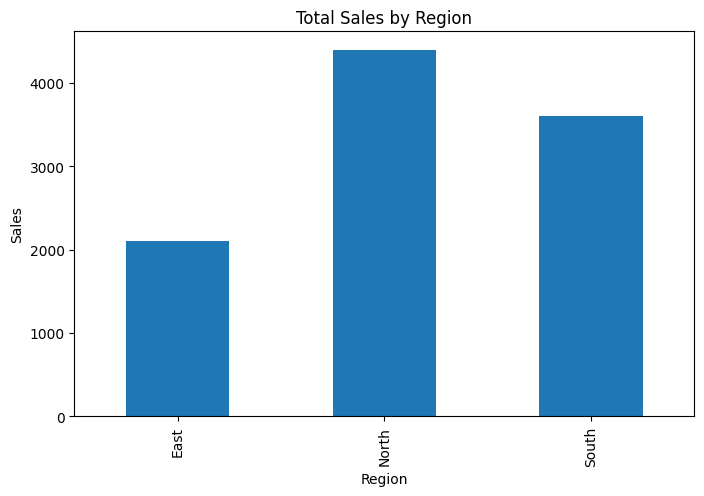

In [14]:
regional_sales = sales.groupby('region')['sales'].sum()

regional_sales.plot(
    kind='bar',
    title='Total Sales by Region',
    xlabel='Region',
    ylabel='Sales',
    figsize=(8, 5)
)


15) Using the same grouped regional sales, create a **Plotly horizontal bar chart** and display the values on the bars using `text_auto`.

In [15]:
import plotly.express as px

regional_sales = (
    sales.groupby('region', as_index=False)['sales']
    .sum()
)

fig = px.bar(
    regional_sales,
    x='sales',
    y='region',
    orientation='h',
    text_auto='.3s',
    title='Total Sales by Region'
)

fig.show()


16) Group `profit` by `region` and create a **Pandas pie chart** showing percentages on the chart using `autopct`.

<Axes: title={'center': 'Profit Distribution by Region'}>

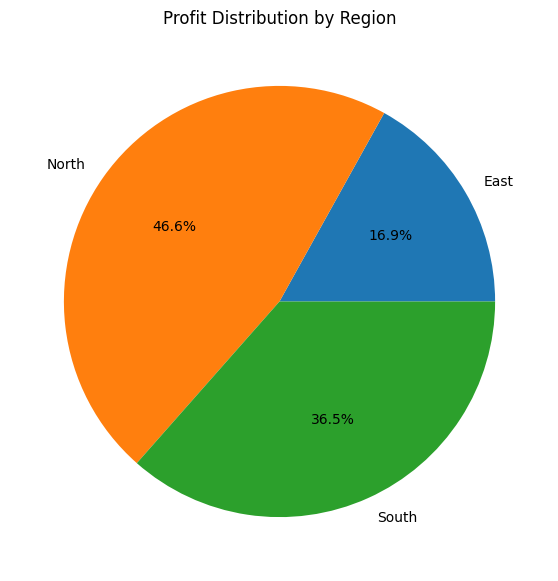

In [16]:
regional_profit = sales.groupby('region')['profit'].sum()

regional_profit.plot(
    kind='pie',
    autopct='%1.1f%%',
    title='Profit Distribution by Region',
    ylabel='',
    figsize=(7, 7)
)


17) Create a **Plotly scatter plot** from `sales` with `profit` on the x-axis, `sales` on the y-axis, and use `region` to color the points.

In [17]:
fig = px.scatter(
    sales,
    x='profit',
    y='sales',
    color='region',
    title='Profit vs Sales'
)

fig.show()


18) Create a **box plot** for the `sales` column using either Pandas or Plotly to inspect its distribution.

In [18]:
fig = px.box(
    sales,
    y='sales',
    title='Sales Distribution'
)

fig.show()


# Section V: Correlation and Heat Map

19) From the `sales` DataFrame, select only the numerical columns and calculate their correlation matrix using `.corr()`.

In [19]:
correlation_matrix = sales.select_dtypes(include='number').corr()

correlation_matrix


,sales,profit,quantity
sales,1.000000,0.985296,0.950437
profit,0.985296,1.000000,0.971762
quantity,0.950437,0.971762,1.000000


20) Create a **Plotly heat map** of the correlation matrix using `px.imshow()`. Display the correlation values inside the cells rounded to 4 decimal places.

In [20]:
fig = px.imshow(
    correlation_matrix,
    text_auto='.4f',
    title='Correlation Heat Map'
)

fig.show()
